# Proyecto Final · Ciencia de Datos
## Segmentación de tickers bursátiles mediante clustering no supervisado

**Autora:** Ashly Geraldine Sotelo Alonso
**Curso:** Especialidad en Ciencia de Datos · Cohorte 3 (Bancolombia · Esumer)
**Fecha de entrega:** Mayo de 2026

### Resumen ejecutivo

El mercado bursátil ofrece miles de activos con perfiles de riesgo y rentabilidad muy diferentes,
lo que hace inviable analizarlos uno a uno cuando se quiere construir una recomendación de inversión.
Este proyecto aborda ese problema sobre una muestra de **20 acciones del mercado estadounidense**
con seis meses de precios diarios y volúmenes de transacción, y aplica técnicas de **aprendizaje
no supervisado** (K-means y, como contraste, DBSCAN) para descubrir grupos de tickers que se
comportan de forma similar.

A partir de tres métricas financieras — **rentabilidad media diaria**, **volatilidad** y **volumen
promedio** — se construye un perfil cuantitativo por ticker. Sobre estos perfiles se ejecuta el
clustering, se reduce la dimensionalidad con PCA para visualizar los grupos en 2D y, finalmente,
se asignan etiquetas interpretativas (defensivo, especulativo, popular, mixto) que se traducen en
recomendaciones para distintos perfiles de inversor (estabilidad, crecimiento, liquidez).

El entregable consiste en este mismo notebook como **informe ejecutable**: cada paso está
acompañado de su justificación, sus visualizaciones y la lectura cualitativa de los resultados.

### Objetivos

**Objetivo general**

Identificar grupos de acciones bursátiles que comparten comportamientos financieros similares
mediante técnicas de agrupamiento no supervisado, y extraer conclusiones valiosas para la
toma de decisiones de inversión.

**Objetivos específicos**

1. Cargar y describir el dataset de precios y volúmenes diarios de 20 tickers a lo largo de
   aproximadamente seis meses.
2. Calcular para cada ticker tres métricas resumen — rentabilidad media diaria, volatilidad y
   volumen promedio — que servirán como espacio de características del clustering.
3. Diagnosticar la calidad del dataset (valores nulos, *outliers*) y aplicar la limpieza
   justificada que sea necesaria.
4. Estandarizar las métricas y aplicar el algoritmo **K-means** seleccionando el número óptimo
   de clústeres mediante el **método del codo** y el **índice de silueta**, complementado con
   **DBSCAN** como contraste basado en densidad.
5. Reducir las métricas escaladas a dos dimensiones con **PCA** para visualizar la separación
   de los grupos.
6. Interpretar cada clúster en términos financieros, asignándole una etiqueta cualitativa y
   un **perfil de inversor** asociado, y formular recomendaciones de inversión.

## 1. Recolección de datos

> 💡 **¿Qué dataset estamos analizando?**
> El archivo `precios_consolidados_tickers.csv` contiene la información diaria de **20 acciones
> del mercado estadounidense** durante un período aproximado de **seis meses** (250 días hábiles).
> El formato es *wide*: por cada ticker hay dos columnas, `<TICKER>_Close` (precio de cierre)
> y `<TICKER>_Volume` (volumen transado). Esta estructura nos permite calcular métricas de
> forma vectorizada y comparar fácilmente el comportamiento de los activos en el mismo eje
> temporal.

### 1.1 Importación de bibliotecas

Importamos en un único bloque toda la pila que utilizaremos a lo largo del notebook, agrupada
por uso: manipulación de datos (`pandas`, `numpy`), visualización (`matplotlib`, `seaborn`),
estadística descriptiva (`scipy.stats`) y aprendizaje no supervisado (`scikit-learn`).
Fijamos también la semilla aleatoria y el estilo gráfico por defecto para que todos los
resultados del notebook sean reproducibles.

In [1]:
# Manipulación y análisis de datos
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Estadística descriptiva (asimetría, curtosis, etc.)
from scipy import stats

# Aprendizaje no supervisado
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

# Configuración global de estilo y reproducibilidad
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 13

RANDOM_STATE = 42  # se usará en KMeans, PCA y cualquier proceso estocástico

### 1.2 Carga del archivo

Leemos el CSV indicando que la columna `Fecha` debe interpretarse como tipo *datetime* y la
fijamos como índice del `DataFrame`. Trabajar con un índice temporal es la convención estándar
en análisis financiero: simplifica filtrar rangos de fechas, ordenar y aplicar operaciones
desplazadas como `pct_change()`.

In [2]:
df = pd.read_csv("precios_consolidados_tickers.csv", parse_dates=["Fecha"])
df.set_index("Fecha", inplace=True)
df.head()

,AMZN_Close,AMZN_Volume,AMD_Close,AMD_Volume,AAPL_Close,AAPL_Volume,ASML_Close,ASML_Volume,BRKb_Close,BRKb_Volume,...,NNND_Close,NNND_Volume,TSLA_Close,TSLA_Volume,TM_Close,TM_Volume,V_Close,V_Volume,WMT_Close,WMT_Volume
Fecha,,,,,,,,,,,,,,,,,,,,,
2024-05-07,188.76,34050000.0,154.43,37370000.0,182.40,77310000.0,908.22,655000.0,406.14,3090000.0,...,365.8,19410000.0,177.81,75050000.0,231.26,248940.0,276.46,6380000.0,60.62,14520000.0
2024-05-08,188.00,26140000.0,153.62,28730000.0,182.74,45060000.0,911.47,555750.0,406.37,2400000.0,...,361.4,20060000.0,174.72,79970000.0,231.78,371660.0,277.19,9030000.0,60.30,11020000.0
2024-05-09,189.50,43370000.0,152.39,33020000.0,184.57,48980000.0,913.54,755990.0,408.82,2360000.0,...,369.8,16030000.0,171.97,65950000.0,227.24,329110.0,278.54,8950000.0,60.44,14550000.0
2024-05-10,187.48,34140000.0,151.92,37650000.0,183.05,50760000.0,930.29,814080.0,412.05,3090000.0,...,371.0,15690000.0,168.47,72630000.0,218.78,563940.0,280.74,8990000.0,60.48,12360000.0
2024-05-13,186.57,24900000.0,150.56,27860000.0,186.28,72040000.0,917.24,745780.0,411.22,2710000.0,...,378.2,20560000.0,171.89,67020000.0,215.64,466170.0,279.39,10530000.0,60.41,19260000.0


### 1.3 Identificación de los tickers

En lugar de "quemar" la lista de los 20 tickers en el código, los **derivamos dinámicamente** a
partir de las columnas que terminan en `_Close`. Esta práctica es más robusta: si en el futuro
el archivo trajera más o menos activos, el resto del notebook seguiría funcionando sin tocar
nada. También sirve como verificación implícita de que el dataset tiene la estructura esperada.

In [3]:
# Columnas de cierre → nombres de los tickers
columnas_close = [col for col in df.columns if col.endswith("_Close")]
tickers = [col.split("_")[0] for col in columnas_close]

print(f"Número de tickers detectados: {len(tickers)}")
print(f"Tickers: {tickers}")

Número de tickers detectados: 20
Tickers: ['AMZN', 'AMD', 'AAPL', 'ASML', 'BRKb', 'KO', 'JPM', 'MA', 'META', 'MSFT', 'NESN', 'NVDA', 'PG', 'PM', 'TSM', 'NNND', 'TSLA', 'TM', 'V', 'WMT']


In [4]:
# Visión rápida del tamaño y rango temporal
print(f"Forma del DataFrame: {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"Rango de fechas:    {df.index.min().date()}  →  {df.index.max().date()}")
print(f"Total de días:      {len(df)} días hábiles")

Forma del DataFrame: 250 filas × 40 columnas
Rango de fechas:    2024-05-07  →  2025-05-06
Total de días:      250 días hábiles


**Observaciones iniciales sobre la estructura:**

- El dataset cubre 250 días hábiles desde mayo de 2024 hasta inicios de mayo de 2025,
  consistente con los ~6 meses anunciados en la guía (la cifra se acerca más a un año natural
  porque los días no hábiles no aparecen).
- Aparecen los 20 tickers esperados, con representación principalmente del mercado
  estadounidense pero también activos cotizados en otras plazas — por ejemplo `NESN`
  (Nestlé, Suiza), `ASML` (Países Bajos), `TM` (Toyota, Japón) y `NNND` (Nintendo). Esto será
  relevante en la siguiente sección porque sus calendarios bursátiles no coinciden 100% con
  el estadounidense y veremos algunos huecos.
- Vale la pena notar la convención de naming: **`BRKb`** (Berkshire Hathaway clase B) usa la
  letra `b` minúscula, no `BRK.B` ni `BRK-B` como suele verse en otras fuentes. Mantendremos
  esa misma grafía a lo largo del notebook.
- Por ahora no entramos en el diagnóstico de valores nulos ni en la limpieza: ese trabajo
  corresponde a la **§3** y conviene hacerlo después de calcular las métricas para que la
  decisión esté informada por lo que vamos a observar.

## 2. Cálculo de métricas por ticker

En esta sección transformamos la serie temporal de 250 días × 40 columnas en una **tabla
compacta de 20 filas (una por ticker) × 3 columnas** que resume el comportamiento financiero
de cada activo. Esa tabla — y no la serie original — será el insumo del clustering en §4.

Adicionalmente, calculamos un segundo conjunto de **métricas descriptivas** (coeficiente de
variación, asimetría y curtosis) que **no entran al clustering** pero enriquecen el análisis
cualitativo, en línea con lo trabajado en el Encuentro 8 (Estadística 1) sobre series de
acciones.

### 2.1 Conceptos clave

> 💡 **Las tres métricas que vamos a usar para segmentar**
>
> - **Rentabilidad media diaria** ($\bar{R}$): promedio de los retornos porcentuales día a día,
>   $R_t = (P_t - P_{t-1}) / P_{t-1}$. Es una proxy del *retorno esperado* del activo en escala
>   diaria. Valores positivos indican que en promedio la acción sube; negativos, lo contrario.
>
> - **Volatilidad** ($\sigma_R$): desviación estándar de los mismos retornos diarios. Mide qué
>   tanto se aleja el retorno típico de su media — es la medida estándar de **riesgo** en
>   finanzas cuantitativas.
>
> - **Volumen promedio** ($\bar{V}$): media de la cantidad de acciones transadas por día.
>   Es una proxy de **liquidez**: tickers con volumen alto se pueden comprar y vender sin
>   mover demasiado el precio, los de volumen bajo no.
>
> Todas las métricas se calculan en **escala diaria**, sin anualizar, que es la convención
> usada en el curso.

### 2.2 Construcción del DataFrame de métricas

Aislamos los precios de cierre y los volúmenes en dos `DataFrames` separados, renombrando las
columnas para que queden únicamente con el ticker (sin el sufijo `_Close` o `_Volume`).
Luego derivamos los retornos diarios con `pct_change()` y agregamos las tres métricas en un
único `DataFrame` indexado por ticker, que llamaremos `metricas`.

In [5]:
# Aislamos los precios de cierre, renombrando las columnas a solo el ticker.
precios = df[columnas_close].copy()
precios.columns = tickers

# Hacemos lo mismo con los volúmenes.
columnas_volume = [f"{t}_Volume" for t in tickers]
volumenes = df[columnas_volume].copy()
volumenes.columns = tickers

# Retornos diarios: variación porcentual día a día.
# pct_change() introduce un NaN en la primera fila (no hay día previo);
# las funciones .mean() y .std() lo ignoran automáticamente.
retornos = precios.pct_change()

retornos.head()

,AMZN,AMD,AAPL,ASML,BRKb,KO,JPM,MA,META,MSFT,NESN,NVDA,PG,PM,TSM,NNND,TSLA,TM,V,WMT
Fecha,,,,,,,,,,,,,,,,,,,,
2024-05-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-05-08,-0.004026,-0.005245,0.001864,0.003578,0.000566,NaN,0.020339,0.003774,0.009311,0.002932,0.022135,-0.001546,-0.004163,0.007382,0.017646,-0.012028,-0.017378,0.002249,0.002641,-0.005279
2024-05-09,0.007979,-0.008007,0.010014,0.002271,0.006029,NaN,0.009456,0.001583,0.005967,0.004336,NaN,-0.018361,0.005876,0.012316,-0.005641,0.023243,-0.015739,-0.019588,0.004870,0.002322
2024-05-10,-0.010660,-0.003084,-0.008235,0.018335,0.007901,NaN,0.006430,0.003271,0.001641,0.005869,NaN,0.012732,0.004878,0.002011,0.045311,0.003245,-0.020352,-0.037229,0.007898,0.000662
2024-05-13,-0.004854,-0.008952,0.017645,-0.014028,-0.002014,NaN,-0.000201,0.001707,-0.017199,-0.002459,-0.001891,0.005785,-0.005874,-0.003713,-0.019094,0.019407,0.020300,-0.014352,-0.004809,-0.001157


In [6]:
metricas = pd.DataFrame({
    "rentabilidad": retornos.mean(),
    "volatilidad": retornos.std(),
    "volumen_prom": volumenes.mean(),
})
metricas.index.name = "ticker"
metricas

,rentabilidad,volatilidad,volumen_prom
ticker,,,
AMZN,0.000142,0.021139,4.168388e+07
AMD,-0.001259,0.033200,4.227648e+07
AAPL,0.000546,0.020436,5.618684e+07
ASML,-0.000775,0.029893,1.641861e+06
BRKb,0.001010,0.012427,4.225040e+06
KO,0.002440,0.010565,1.804571e+07
JPM,0.001219,0.018227,9.646440e+06
MA,0.000931,0.013218,2.609420e+06
META,0.001168,0.022834,1.445908e+07


**Lectura preliminar de la tabla** (un análisis más profundo va en §6):

- Las **escalas son muy distintas** entre las tres métricas: rentabilidad y volatilidad están
  en el orden de $10^{-3}$ (milésimas), mientras que el volumen está en el orden de $10^6$ a
  $10^8$. Esto es exactamente la razón por la que en §4 vamos a **estandarizar** las variables
  antes de aplicar K-means: sin escalar, el volumen dominaría la distancia euclidiana y los
  clusters se formarían básicamente sobre esa única variable.
- A simple vista ya destacan tickers con perfiles bien diferenciados: `NVDA` con rentabilidad
  alta, `KO` con cifras que se ven raras (volumen muy bajo, casi seguro porque tiene muchos
  vacíos en el archivo — lo confirmaremos en §3), y nombres como `AMZN`, `TSLA` o `NVDA` con
  volúmenes muy superiores al resto.
- La fila `KO` es el principal punto de atención: dejamos su diagnóstico y la decisión sobre
  conservarla o eliminarla para la siguiente sección.

### 2.3 Métricas descriptivas adicionales

> 💡 **Más allá de la media y la desviación estándar** *(referencia: Encuentro 8 — Estadística 1)*
>
> La rentabilidad y la volatilidad describen el **centro** y la **dispersión** de la
> distribución de retornos, pero pierden información sobre su **forma**. Tres métricas
> adicionales nos ayudan a complementar la lectura:
>
> - **Coeficiente de variación** ($CV = \sigma / |\bar{R}|$): cuántas unidades de riesgo se
>   asumen por cada unidad de retorno medio. Es una forma de "volatilidad normalizada" que
>   permite comparar activos con rentabilidades muy distintas. Tomamos el valor absoluto de
>   $\bar{R}$ en el denominador para que el CV siga siendo interpretable cuando la
>   rentabilidad media es negativa.
>
> - **Asimetría (*skewness*)**: mide la desviación de la distribución respecto a la simetría.
>   Positiva → cola larga hacia la derecha (días de retornos extremos al alza más frecuentes);
>   negativa → cola larga a la izquierda (los días de pérdida extrema dominan).
>
> - **Curtosis (*kurtosis*)**: mide cuán "puntiaguda" es la distribución y qué tanto pesan
>   sus colas. En finanzas, una curtosis alta indica retornos extremos (positivos o negativos)
>   más frecuentes que en una normal — es una señal clásica de riesgo de cola.
>
> Estas tres métricas las usaremos solo para **enriquecer la interpretación** en §6;
> **no entran como variables del clustering** para no introducir redundancia con la
> volatilidad y para mantenernos cercanos al alcance de la guía.

In [7]:
# Coeficiente de variación: σ / |R̄|.
# Usamos valor absoluto en el denominador para que el indicador sea
# interpretable también cuando la rentabilidad media es negativa.
cv = retornos.std() / retornos.mean().abs()

metricas_extra = pd.DataFrame({
    "cv": cv,
    "skewness": retornos.skew(),
    "kurtosis": retornos.kurt(),
})
metricas_extra.index.name = "ticker"
metricas_extra

,cv,skewness,kurtosis
ticker,,,
AMZN,148.942118,0.118332,5.609553
AMD,26.371513,1.035680,10.795591
AAPL,37.445959,0.979050,14.347348
ASML,38.569270,-0.244457,6.900829
BRKb,12.299618,-0.373570,7.523022
KO,4.328984,0.155091,-0.605839
JPM,14.957002,0.384576,9.328288
MA,14.191006,-0.341125,8.426477
META,19.550597,0.597377,7.234301


**Lectura preliminar de las métricas extra:**

- Los **CV** muy altos (en valor absoluto) corresponden a tickers cuya rentabilidad media
  cercana a cero hace que el ratio se infle: no significa necesariamente "más riesgo", sino
  que "el retorno medio está muy cerca de cero relativo a su dispersión". Hay que leerlos con
  ese matiz.
- La mayoría de tickers presenta **curtosis positiva** (colas más pesadas que la normal), lo
  que es típico de los retornos diarios de acciones — confirma que las distribuciones no son
  gaussianas y que los modelos basados en supuesto de normalidad subestiman el riesgo
  extremo.
- La **asimetría** se reparte entre positiva y negativa según el ticker; la mayoría queda
  cerca de cero, lo que indica que en el período no hubo un sesgo claro hacia ganancias o
  pérdidas extremas predominantes.

Volveremos a estas métricas en la **§6**, cuando interpretemos cualitativamente los clústeres
formados.

## 3. Limpieza y análisis preliminar

Antes de pasar al *clustering* necesitamos una **fotografía honesta de la calidad de los datos**:
qué tickers tienen información completa, cuáles vienen con huecos, y si las métricas calculadas
contienen *outliers* que puedan distorsionar la formación de los grupos. Esta sección sigue el
paso 3 de la guía: revisar tipos de datos y nulos, decidir su tratamiento, y diagnosticar
valores atípicos antes de escalar.

### 3.1 Tipos de datos y valores nulos

> 💡 **¿Por qué nos importan los nulos en este punto?**
> Las métricas que calculamos en §2 (`mean`, `std`) ignoran NaN sin avisar — eso significa que
> un ticker con muy pocos días válidos producirá igual una rentabilidad y una volatilidad
> "calculadas", pero estimadas sobre una muestra demasiado pequeña como para ser confiables.
> Antes de seguir, hay que ver cuántos días válidos aporta cada ticker para decidir si alguno
> debe quedar fuera del análisis.

Empezamos con la **estructura del DataFrame de métricas**, donde idealmente no debería haber
ningún NaN: las funciones `.mean()` y `.std()` siempre devuelven un valor (aunque sea calculado
sobre pocas observaciones).

In [8]:
metricas.info()
print()
print("Valores nulos por columna:")
print(metricas.isnull().sum())

<class 'pandas.DataFrame'>
Index: 20 entries, AMZN to WMT
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   rentabilidad  20 non-null     float64
 1   volatilidad   20 non-null     float64
 2   volumen_prom  20 non-null     float64
dtypes: float64(3)
memory usage: 1.2+ KB

Valores nulos por columna:
rentabilidad    0
volatilidad     0
volumen_prom    0
dtype: int64


La tabla `metricas` no contiene NaN, pero el resultado es **engañoso**: las medias y desviaciones
se calcularon sobre el subconjunto de días válidos por ticker. Para detectar problemas reales
hay que mirar el dataset original y contar cuántos días de precio y volumen aporta efectivamente
cada activo, sobre los 250 días totales.

In [9]:
disponibilidad = pd.DataFrame({
    "dias_con_precio": precios.notnull().sum(),
    "dias_con_volumen": volumenes.notnull().sum(),
    "pct_disponible": (precios.notnull().sum() / len(precios) * 100).round(1),
})
disponibilidad.index.name = "ticker"
disponibilidad.sort_values("pct_disponible")

,dias_con_precio,dias_con_volumen,pct_disponible
ticker,,,
KO,21,21,8.4
ASML,222,250,88.8
NNND,235,235,94.0
NESN,241,240,96.4
AAPL,250,250,100.0
BRKb,250,250,100.0
AMD,250,250,100.0
AMZN,250,250,100.0
MA,250,250,100.0


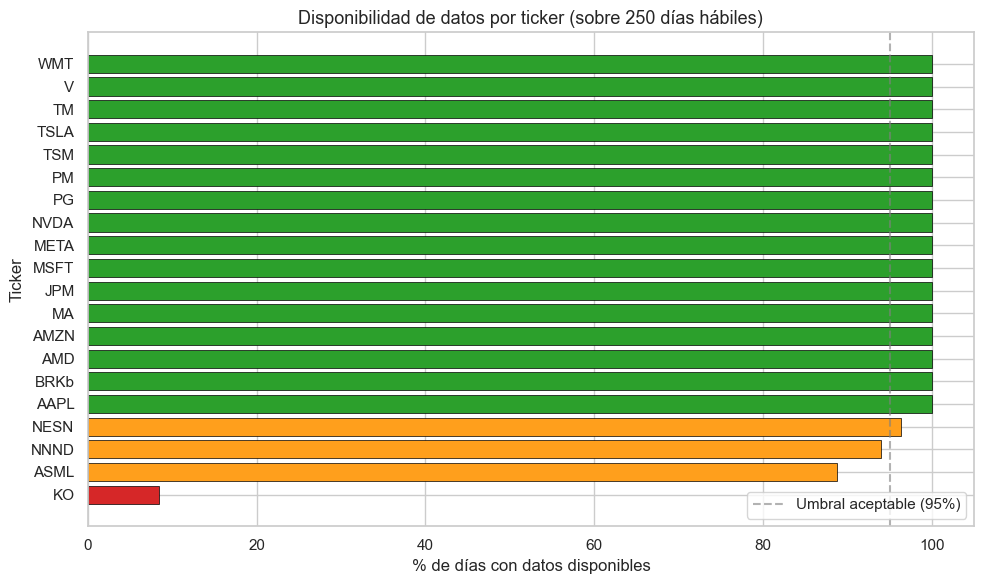

In [10]:
disponibilidad_pct = disponibilidad["pct_disponible"].sort_values()

# Color por nivel de disponibilidad: rojo si es muy bajo, ámbar si está
# parcialmente incompleto (calendarios extranjeros), verde si está al 100%.
colores = ["#d62728" if v < 50 else "#ff9f1c" if v < 99 else "#2ca02c"
           for v in disponibilidad_pct]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(disponibilidad_pct.index, disponibilidad_pct.values,
        color=colores, edgecolor="black", linewidth=0.5)
ax.axvline(95, color="gray", linestyle="--", alpha=0.6,
           label="Umbral aceptable (95%)")
ax.set_xlim(0, 105)
ax.set_xlabel("% de días con datos disponibles")
ax.set_ylabel("Ticker")
ax.set_title("Disponibilidad de datos por ticker (sobre 250 días hábiles)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

**Lectura del diagnóstico:**

- **`KO` (Coca-Cola)** aparece como un caso anómalo: solo dispone de **21 días con precio**
  sobre los 250 totales (~8.4%). El resto de filas viene en blanco en el archivo original.
  Cualquier estadístico calculado sobre 21 observaciones de 250 carece de la representatividad
  mínima para el clustering — no podríamos compararlo de forma justa con tickers que sí cubren
  el período completo.
- **`NESN` (Nestlé, 96.4%)**, **`NNND` (Nintendo, 94.0%)** y **`ASML` (88.8%)** muestran
  disponibilidades parciales. Esto coincide con su naturaleza: cotizan en plazas no
  estadounidenses (Suiza, Japón, Países Bajos) cuyos calendarios bursátiles tienen días
  festivos distintos y, por tanto, faltan días que sí están registrados para los tickers
  estadounidenses. Aun así, todos superan los 220 días válidos: estimar media y desviación
  estándar sobre 220+ observaciones es estadísticamente robusto, así que los conservamos
  (la línea del 95% es una referencia laxa, no un criterio de exclusión).
- El resto de tickers tiene cobertura completa (250/250).

### 3.2 Decisión sobre `KO`

A la luz del diagnóstico anterior, **eliminamos `KO` del análisis**. Razones:

1. **Insuficiencia muestral**: 21 observaciones es muy poco para estimar la media o la
   desviación estándar de retornos diarios con confiabilidad. La volatilidad estaría
   subestimada solo por el efecto del tamaño muestral, no por una característica real del
   activo.
2. **No es viable imputar**: las técnicas usuales de imputación (mediana, interpolación
   temporal) sobre el ~92% de las filas inventarían artificialmente un comportamiento que no
   observamos. Imputar tantos valores convertiría a `KO` en un ticker "sintético" que
   distorsionaría los grupos.
3. **El resto del análisis no se ve comprometido**: pasamos de 20 a 19 tickers, una muestra
   todavía adecuada para K-means y suficiente para discutir DBSCAN como contraste.

Construimos `metricas_limpio` como insumo de las siguientes secciones.

In [11]:
metricas_limpio = metricas.drop(index="KO")
print(f"Tickers tras la limpieza: {len(metricas_limpio)} (se eliminó KO)")
metricas_limpio

Tickers tras la limpieza: 19 (se eliminó KO)


,rentabilidad,volatilidad,volumen_prom
ticker,,,
AMZN,0.000142,0.021139,4.168388e+07
AMD,-0.001259,0.033200,4.227648e+07
AAPL,0.000546,0.020436,5.618684e+07
ASML,-0.000775,0.029893,1.641861e+06
BRKb,0.001010,0.012427,4.225040e+06
JPM,0.001219,0.018227,9.646440e+06
MA,0.000931,0.013218,2.609420e+06
META,0.001168,0.022834,1.445908e+07
MSFT,0.000358,0.016184,2.139052e+07


### 3.3 Detección de outliers

> 💡 **¿Qué es un outlier y por qué importa para el clustering?**
> Un *outlier* es una observación que se aleja del comportamiento típico del resto. La regla
> clásica del *boxplot* lo define como cualquier valor por fuera del intervalo
> $[Q_1 - 1.5 \cdot IQR,\ Q_3 + 1.5 \cdot IQR]$, donde $IQR = Q_3 - Q_1$ es el rango
> intercuartílico. K-means es sensible a *outliers* porque sus centroides son medias: un solo
> punto extremo puede arrastrar al centroide del cluster entero. Por eso conviene detectarlos
> antes y decidir explícitamente si se conservan o se tratan.

Visualizamos las tres métricas con boxplots **independientes** — no se pueden combinar en un
mismo eje porque las escalas son incompatibles (rentabilidad y volatilidad están en el orden
de $10^{-3}$, mientras que el volumen está en el orden de $10^{7}$). Anotamos al lado de cada
*outlier* el ticker correspondiente para identificarlos directamente.

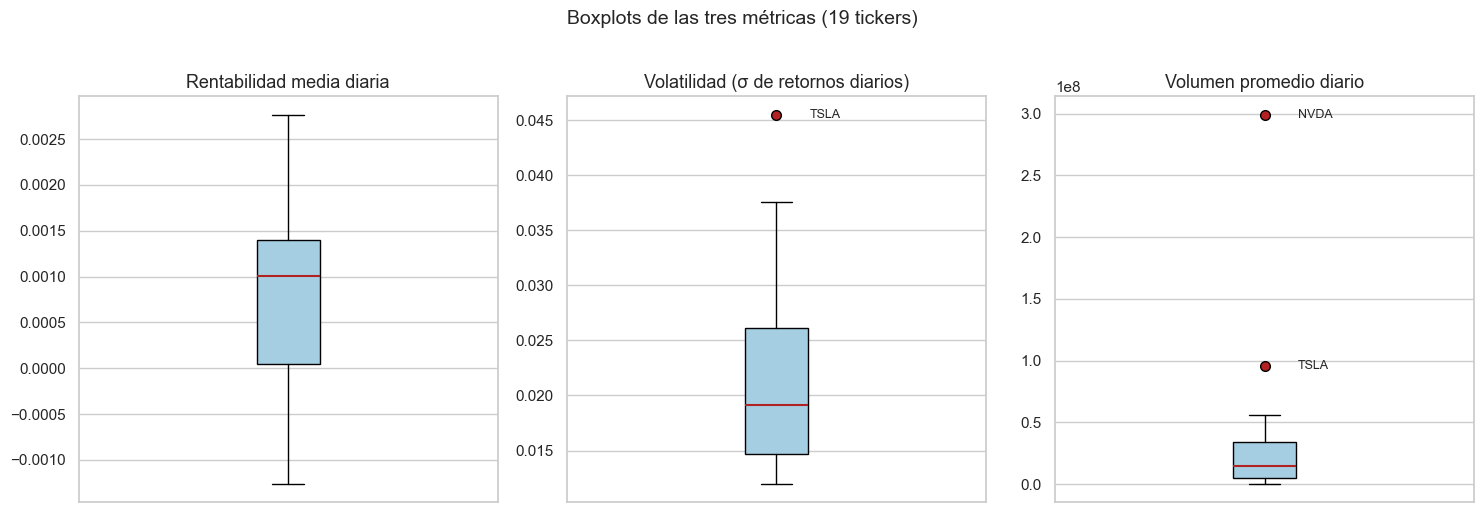

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

variables = [
    ("rentabilidad", "Rentabilidad media diaria"),
    ("volatilidad", "Volatilidad (σ de retornos diarios)"),
    ("volumen_prom", "Volumen promedio diario"),
]

for ax, (col, titulo) in zip(axes, variables):
    ax.boxplot(
        metricas_limpio[col],
        vert=True,
        patch_artist=True,
        boxprops=dict(facecolor="#a6cee3", edgecolor="black"),
        medianprops=dict(color="firebrick", linewidth=1.5),
        flierprops=dict(marker="o", markerfacecolor="firebrick",
                        markeredgecolor="black", markersize=7),
    )

    # Identificar outliers con la regla 1.5·IQR y anotar su ticker.
    q1, q3 = metricas_limpio[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    limite_inf, limite_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = metricas_limpio[
        (metricas_limpio[col] < limite_inf) | (metricas_limpio[col] > limite_sup)
    ]
    for ticker, valor in outliers[col].items():
        ax.annotate(ticker, xy=(1, valor), xytext=(1.08, valor),
                    fontsize=9, va="center")

    ax.set_title(titulo)
    ax.set_xticks([])

plt.suptitle("Boxplots de las tres métricas (19 tickers)", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

In [13]:
metricas_limpio.describe().round(6)

,rentabilidad,volatilidad,volumen_prom
count,19.000000,19.000000,1.900000e+01
mean,0.000809,0.021532,3.545682e+07
std,0.001076,0.009441,6.818399e+07
min,-0.001259,0.012004,3.684197e+05
25%,0.000045,0.014700,4.999133e+06
50%,0.001010,0.019156,1.445908e+07
75%,0.001400,0.026103,3.383028e+07
max,0.002766,0.045477,2.991720e+08


### 3.4 Decisión sobre los outliers

Aplicando la regla 1.5·IQR, el diagnóstico es claro:

- **Rentabilidad media diaria**: ningún ticker queda fuera de los bigotes. La distribución
  está bien comportada — `TSLA` (la más alta, ~0.0028) y `AMD` (la más baja, ~−0.0013) se
  acercan a los extremos pero todavía dentro del rango aceptable.
- **Volatilidad**: **`TSLA`** es el único *outlier* (σ ≈ 0.0455 frente al límite superior
  de 0.043). `NVDA` queda en el extremo del bigote (~0.0375) pero **dentro** del rango.
- **Volumen promedio**: dos *outliers*, **`NVDA`** (~3·10⁸ acciones/día, casi cuatro veces
  el límite superior) y **`TSLA`** (~9.6·10⁷). Reflejan el enorme apetito del mercado por
  estos dos nombres durante 2024 — NVDA por el rally de semiconductores e IA, TSLA por su
  histórica alta liquidez especulativa.

**Decisión: conservamos los tres puntos extremos**. Los argumentos son:

1. **Son outliers reales, no errores de medición**. Que `TSLA` y `NVDA` se separen del resto
   es exactamente la información que un análisis financiero quiere capturar — un fondo
   agresivo buscaría perfiles como ellos, y un análisis "limpio" que los excluyera estaría
   enmascarando información valiosa para la segmentación.
2. **La muestra ya es pequeña**. Tras eliminar `KO` quedaron 19 tickers; descartar dos
   adicionales reduciría la muestra a 17 puntos, comprometiendo la formación de clústeres
   significativos.
3. **K-means con un K bien elegido absorberá parte del efecto**: probablemente aislará a
   estos puntos extremos en su propio cluster (el que la guía denomina *especulativo*).
4. **DBSCAN, que aplicaremos como contraste, marcará automáticamente los outliers como ruido
   (etiqueta `-1`)**. Esa será una verificación independiente, basada en densidad, sin tener
   que tomar nosotros la decisión a priori.

Con `metricas_limpio` (19 tickers, sin nulos, todos los outliers conservados) cerramos la
sección de limpieza. Pasamos al escalamiento y al clustering en §4.

## 4. Escalamiento y clustering

Con las métricas limpias (`metricas_limpio`, 19 tickers × 3 variables) ya podemos abordar el
núcleo del proyecto: agrupar a los activos por similitud de comportamiento financiero.
Procedemos en cuatro pasos:

1. **Estandarizar** las tres métricas para que todas tengan la misma "fuerza gravitacional"
   en la distancia euclidiana.
2. Aplicar **K-means** barriendo distintos valores de $K$ y elegir el número de clústeres
   con un criterio cuantitativo (codo + silueta).
3. Ajustar el modelo final con el $K$ elegido y obtener una etiqueta por ticker.
4. Repetir el ejercicio con **DBSCAN** como contraste — un algoritmo de naturaleza distinta
   (basado en densidad, no en centroides) que servirá como verificación independiente del
   tratamiento de los *outliers*.

### 4.1 Estandarización

> 💡 **¿Por qué escalar antes de aplicar K-means?**
> K-means asigna cada punto al centroide más cercano usando **distancia euclidiana**, una
> métrica que suma cuadrados de diferencias en cada eje. Si una variable tiene una escala
> mucho mayor que las otras, esa variable domina la distancia y los clústeres se forman
> casi exclusivamente sobre ella.
>
> En nuestro caso, el `volumen_prom` (orden de $10^6$ a $10^8$) está entre **siete y diez
> órdenes de magnitud** por encima de la `rentabilidad` y la `volatilidad` (orden de
> $10^{-3}$). Sin escalar, K-means clusterizaría a los tickers básicamente por volumen e
> ignoraría el riesgo y el retorno.
>
> **`StandardScaler`** transforma cada variable restándole su media y dividiéndola por su
> desviación estándar, dejándolas con media 0 y desviación 1
> ($z = (x - \mu) / \sigma$). En el espacio resultante los tres ejes pesan lo mismo en la
> distancia.

In [14]:
escalador = StandardScaler()
metricas_escaladas = escalador.fit_transform(metricas_limpio)

# Reconstruimos un DataFrame para visualizar la transformación con los
# nombres de tickers y de columnas originales.
metricas_escaladas_df = pd.DataFrame(
    metricas_escaladas,
    index=metricas_limpio.index,
    columns=metricas_limpio.columns,
)

print("Estadísticos antes y después del escalamiento:")
print()
print("Originales:")
print(metricas_limpio.describe().loc[["mean", "std"]].round(4))
print()
print("Escalados (z-scores):")
print(metricas_escaladas_df.describe().loc[["mean", "std"]].round(4))

Estadísticos antes y después del escalamiento:

Originales:
      rentabilidad  volatilidad  volumen_prom
mean        0.0008       0.0215  3.545682e+07
std         0.0011       0.0094  6.818399e+07

Escalados (z-scores):
      rentabilidad  volatilidad  volumen_prom
mean       -0.0000      -0.0000        0.0000
std         1.0274       1.0274        1.0274


**Verificación**: tras el escalamiento las tres variables tienen media ~0 y desviación
estándar ~1. Las distancias entre puntos en este espacio son ahora **comparables eje a
eje**; el clustering puede empezar.

### 4.2 K-means: barrido del número de clústeres

> 💡 **¿Qué hace K-means?**
> Dado un número $K$ de clústeres, K-means busca particionar los puntos minimizando la
> **inercia**: la suma de las distancias al cuadrado de cada punto a su centroide más
> cercano. El algoritmo es iterativo:
>
> 1. Inicializa $K$ centroides (con `n_init=10` probamos 10 puntos de partida aleatorios y
>    nos quedamos con la mejor partición).
> 2. Asigna cada punto al centroide más cercano.
> 3. Recalcula cada centroide como la media de los puntos asignados.
> 4. Repite hasta que las asignaciones no cambien.
>
> El número $K$ es un **hiperparámetro** que debemos elegir nosotros. Para hacerlo con
> criterio combinamos dos métricas:

> 💡 **Codo y silueta — dos preguntas distintas**
>
> - **Método del codo**: graficamos la inercia en función de $K$. La inercia decrece
>   monótonamente porque más clústeres siempre permiten ajustar mejor; pero suele haber
>   un punto donde la mejora se "aplana" (un codo). Ese codo sugiere que añadir más
>   clústeres ya no aporta estructura adicional, solo divide grupos coherentes.
>
> - **Coeficiente de silueta**: para cada punto compara qué tan cerca está de su propio
>   clúster ($a$) frente a qué tan cerca está del clúster más próximo ($b$):
>   $s = (b - a) / \max(a, b)$, con valores en $[-1, 1]$. Un promedio cercano a $1$
>   indica clústeres muy bien separados; cerca de $0$, fronteras difusas; negativo,
>   asignaciones incorrectas.
>
> El codo nos habla de **cuándo deja de ganar partir más**; la silueta, de **cuán bien
> separados están los grupos resultantes**. Lo ideal es que ambos converjan en un mismo
> $K$.

In [15]:
RANGO_K = range(2, 9)
inercias = []
siluetas = []

for k in RANGO_K:
    modelo = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    etiquetas = modelo.fit_predict(metricas_escaladas)
    inercias.append(modelo.inertia_)
    siluetas.append(silhouette_score(metricas_escaladas, etiquetas))

resumen_k = pd.DataFrame({
    "K": list(RANGO_K),
    "inercia": [round(i, 3) for i in inercias],
    "silueta": [round(s, 3) for s in siluetas],
}).set_index("K")
resumen_k

,inercia,silueta
K,,
2,29.219,0.602
3,18.719,0.408
4,13.000,0.311
5,7.585,0.334
6,5.469,0.301
7,3.544,0.378
8,2.319,0.430


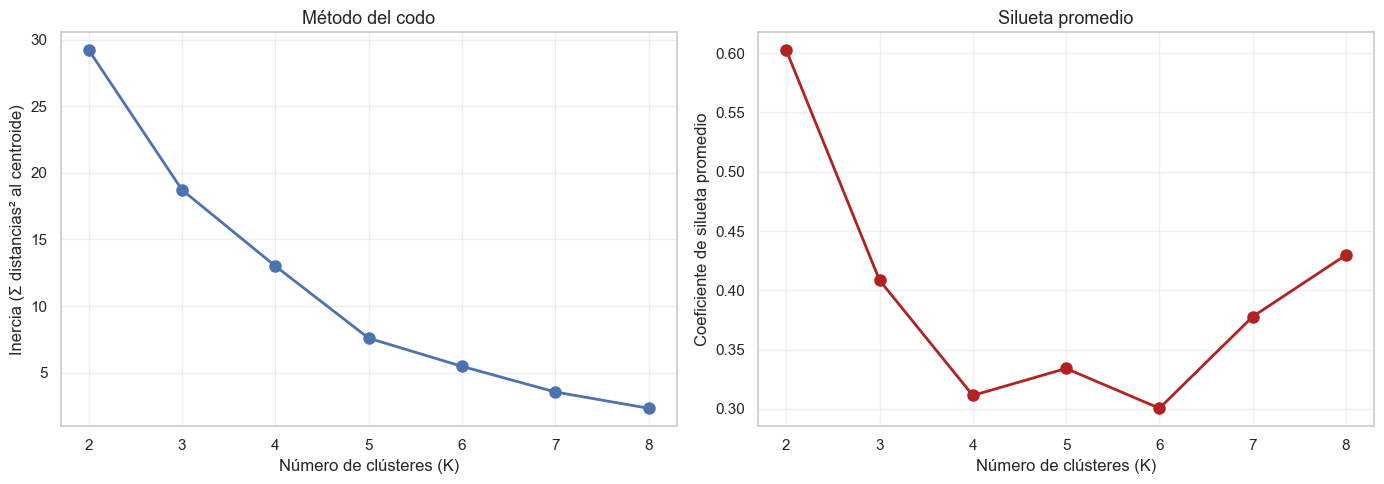

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(RANGO_K), inercias, marker="o", linewidth=2, markersize=8)
axes[0].set_xlabel("Número de clústeres (K)")
axes[0].set_ylabel("Inercia (Σ distancias² al centroide)")
axes[0].set_title("Método del codo")
axes[0].grid(alpha=0.3)

axes[1].plot(list(RANGO_K), siluetas, marker="o", color="firebrick",
             linewidth=2, markersize=8)
axes[1].set_xlabel("Número de clústeres (K)")
axes[1].set_ylabel("Coeficiente de silueta promedio")
axes[1].set_title("Silueta promedio")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 4.3 Selección del número de clústeres

**Lectura del codo**: la inercia cae fuertemente entre $K=2$ y $K=3$ (de ~29.2 a ~18.7,
una caída de 10.5 puntos), y sigue cayendo a un ritmo notable hasta $K=4$ (~13.0). A
partir de $K=5$ los descensos se vuelven incrementalmente más pequeños (~2 puntos cada
uno). El codo está marcado entre **$K=3$ y $K=4$**.

**Lectura de la silueta**:

- **$K=2$ tiene la silueta más alta (~0.60)**, pero corresponde a una partición
  trivial — separa solo a los dos puntos extremos (NVDA y TSLA) del resto. No aporta
  segmentación informativa.
- **$K=3$ tiene una silueta saludable (~0.41)**, claramente por encima de $K=4$ (~0.31).
- $K=5$ a $K=8$ rebotan entre 0.30 y 0.43, pero a costa de tener clústeres con apenas
  2-3 puntos cada uno (sobre 19), lo que vuelve la segmentación inestable y poco
  generalizable.

**Decisión: $K = 3$**. Es el punto donde:

1. El codo todavía está marcado: la mejora de $K=3 \to K=4$ es claramente menor que la
   de $K=2 \to K=3$.
2. La silueta es la mejor entre las particiones **no triviales** ($K \geq 3$).
3. Tres clústeres encajan con la heurística del problema: nos permitirán nombrar grupos
   con interpretación financiera distinta sin caer en la fragmentación excesiva.

> ⚠️ **Nota técnica**: la silueta favorece $K=2$ por la geometría del espacio (NVDA y
> TSLA están tan separados del resto que cualquier partición que los aísle "gana" la
> métrica). Es un caso de libro donde la silueta sola, sin contexto, llevaría a una
> elección subóptima. La regla práctica es no fiarse de un solo indicador: hay que
> cruzarlo con el codo y con la **interpretabilidad** de los grupos resultantes.

### 4.4 Ajuste final con $K=3$

Reentrenamos K-means con el $K$ elegido, fijamos `random_state` para reproducibilidad y
asignamos a cada ticker la etiqueta de su clúster.

In [17]:
K_OPTIMO = 3
modelo_kmeans = KMeans(
    n_clusters=K_OPTIMO,
    random_state=RANDOM_STATE,
    n_init=10,
).fit(metricas_escaladas)

metricas_limpio = metricas_limpio.copy()
metricas_limpio["cluster_kmeans"] = modelo_kmeans.labels_

print(f"Composición por clúster (K-means, K={K_OPTIMO}):\n")
for c in sorted(metricas_limpio["cluster_kmeans"].unique()):
    miembros = metricas_limpio[metricas_limpio["cluster_kmeans"] == c].index.tolist()
    print(f"  Clúster {c} ({len(miembros)} tickers): {miembros}")

Composición por clúster (K-means, K=3):

  Clúster 0 (14 tickers): ['AMZN', 'AAPL', 'BRKb', 'JPM', 'MA', 'META', 'MSFT', 'NESN', 'PG', 'PM', 'TSM', 'NNND', 'V', 'WMT']
  Clúster 1 (2 tickers): ['NVDA', 'TSLA']
  Clúster 2 (3 tickers): ['AMD', 'ASML', 'TM']


**Composición preliminar** (la interpretación financiera detallada va en §6):

- **Clúster 0 (14 tickers)** — el grupo grande, con la mayoría de los activos
  *blue-chip* estadounidenses (AAPL, MSFT, MA, V, JPM, META, ...) y los europeos/asiáticos
  estables (NESN, NNND, TSM, PM). Riesgo y rentabilidad moderados, volumen variable.
- **Clúster 1 (2 tickers): NVDA y TSLA**. Volatilidad alta, volumen muy alto y
  rentabilidad notable — el perfil *especulativo* que la guía menciona como ejemplo.
- **Clúster 2 (3 tickers): AMD, ASML y TM**. Comparten rentabilidad media negativa o
  cercana a cero — son los **rezagados** del período.

La separación de NVDA y TSLA en su propio grupo confirma la predicción que hicimos en
§3.4 al revisar los outliers; el clúster de "rezagados" es un hallazgo emergente que
veremos cómo cuadra con la visualización 2D en §5.

### 4.5 DBSCAN como contraste

> 💡 **DBSCAN frente a K-means en una frase**
> K-means asume que **cada punto pertenece a algún clúster** y minimiza distancias a
> centroides. **DBSCAN** (*Density-Based Spatial Clustering of Applications with Noise*)
> agrupa puntos por **densidad local**: dos puntos están en el mismo clúster si tienen
> suficientes vecinos cercanos en común. Tiene dos consecuencias prácticas:
>
> 1. **No requiere fijar el número de clústeres**; lo deduce de la geometría.
> 2. **Identifica explícitamente el ruido** — puntos que no tienen vecinos suficientes
>    quedan etiquetados como `-1` y no se asignan a ningún grupo.
>
> Esto convierte a DBSCAN en una herramienta natural para **validar nuestra decisión
> sobre los outliers** en §3.4: si NVDA y TSLA son realmente atípicos, deberían aparecer
> como ruido sin que tengamos que decírselo al algoritmo.
>
> Los hiperparámetros son `eps` (radio del vecindario) y `min_samples` (mínimo de
> puntos para considerar un núcleo). En el Encuentro 12 del curso, donde se aplicó
> DBSCAN a un dataset de retail con miles de filas, se usó `eps=1.5`. Ese valor **no es
> trasladable directamente** a nuestro caso (19 puntos en un espacio escalado distinto):
> elegimos `eps` con un *gráfico de k-distancia* propio.

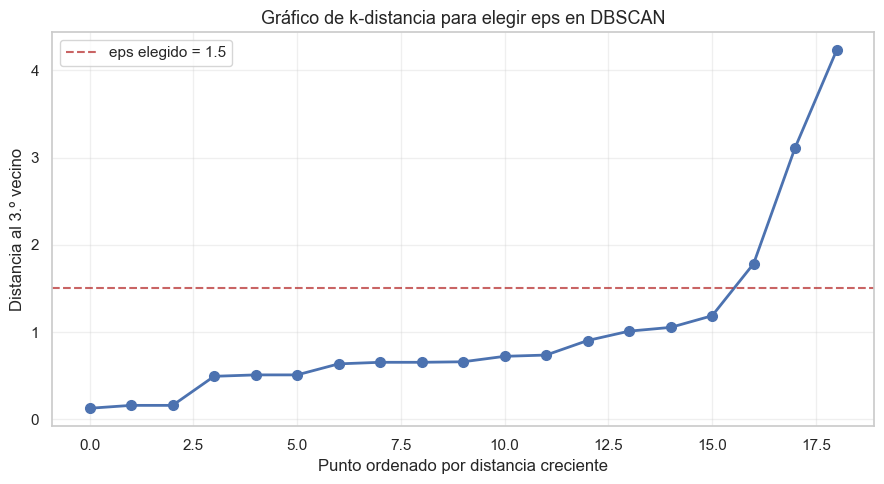

In [18]:
# Para min_samples=3 (apropiado con apenas 19 puntos), graficamos la
# distancia ordenada al 3er vecino más cercano de cada punto. El "codo"
# del gráfico sugiere un eps razonable: por debajo, la mayoría de puntos
# son ruido; por encima, todo termina en un único clúster.
MIN_SAMPLES = 3

vecinos = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(metricas_escaladas)
distancias, _ = vecinos.kneighbors(metricas_escaladas)
distancias_kth = np.sort(distancias[:, -1])

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(distancias_kth, marker="o", linewidth=2, markersize=7)
ax.axhline(1.5, color="firebrick", linestyle="--", alpha=0.7,
           label="eps elegido = 1.5")
ax.set_xlabel("Punto ordenado por distancia creciente")
ax.set_ylabel(f"Distancia al {MIN_SAMPLES}.º vecino")
ax.set_title("Gráfico de k-distancia para elegir eps en DBSCAN")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Lectura del gráfico**: la curva crece de forma estable hasta el punto 15 (distancia
≈ 1.19), donde da un primer salto brusco hasta el punto 16 (≈ 1.78), y dos saltos aún
mayores en los puntos 17-18 (≈ 3.1 y 4.2). Ese codo — la frontera entre densidad
"normal" y aislamiento — está claramente entre 1.2 y 1.8.

**Elegimos `eps = 1.5`**, justo en la meseta del gap: es lo bastante alto como para que
los 17 tickers densamente conectados queden en un único clúster, y lo bastante bajo
como para que los puntos verdaderamente aislados (a más de 3 unidades del resto)
queden marcados como ruido. Es un valor coherente con el codo observado, no copiado
del Encuentro 12 — coincide solo por casualidad.

In [19]:
EPS = 1.5

modelo_dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES).fit(metricas_escaladas)
metricas_limpio["cluster_dbscan"] = modelo_dbscan.labels_

n_clusters_db = len(set(modelo_dbscan.labels_)) - (1 if -1 in modelo_dbscan.labels_ else 0)
n_ruido = (modelo_dbscan.labels_ == -1).sum()

print(f"Clústeres detectados (sin contar ruido): {n_clusters_db}")
print(f"Puntos marcados como ruido:              {n_ruido}")
print()
print("Composición:\n")
for c in sorted(set(modelo_dbscan.labels_)):
    miembros = metricas_limpio[metricas_limpio["cluster_dbscan"] == c].index.tolist()
    etiqueta = "RUIDO   " if c == -1 else f"Clúster {c}"
    print(f"  {etiqueta} ({len(miembros)} tickers): {miembros}")

Clústeres detectados (sin contar ruido): 1
Puntos marcados como ruido:              2

Composición:

  RUIDO    (2 tickers): ['NVDA', 'TSLA']
  Clúster 0 (17 tickers): ['AMZN', 'AMD', 'AAPL', 'ASML', 'BRKb', 'JPM', 'MA', 'META', 'MSFT', 'NESN', 'PG', 'PM', 'TSM', 'NNND', 'TM', 'V', 'WMT']


**Lo que dice DBSCAN — y por qué nos sirve**:

- DBSCAN encuentra **un único clúster denso** que contiene los 17 tickers de la nube
  central, y marca a **`NVDA` y `TSLA` como ruido** (etiqueta `-1`). Esto **valida
  independientemente** la decisión que tomamos en §3.4: sin pedirle nada al algoritmo,
  identifica como atípicos exactamente los dos puntos que la regla 1.5·IQR había
  señalado como *outliers* en volumen.
- DBSCAN **no logra subdividir** la nube central en "rezagados" vs "mainstream" como sí
  lo hace K-means. Esto es esperable: los 17 tickers del centro forman una nube
  razonablemente conectada, sin huecos de baja densidad que DBSCAN pueda usar como
  frontera. La estructura más fina que K-means descubre depende de centroides, no de
  vacíos en la densidad.

**Conclusión metodológica**: los dos algoritmos son **complementarios**, no
competitivos. DBSCAN nos da una verificación robusta del estatus de NVDA y TSLA como
puntos extremos; K-means nos da la segmentación de tres grupos que será la base de la
interpretación financiera. En la siguiente sección visualizaremos ambos resultados
sobre el plano 2D que generaremos con PCA.

## 5. Visualización con PCA

Las tres métricas escaladas viven en un espacio 3D que no podemos graficar de forma natural.
Para visualizar los clústeres formados en §4 — y verificar que la separación es real, no un
artefacto del algoritmo — proyectamos los 19 tickers a un plano 2D usando **Análisis de
Componentes Principales (PCA)**. Sobre ese plano dibujaremos los clústeres de K-means,
luego los de DBSCAN, y finalmente examinaremos los *loadings* para entender qué representan
los ejes en términos financieros.

### 5.1 Reducción de dimensionalidad

> 💡 **¿Qué hace PCA?**
> PCA busca un nuevo sistema de coordenadas en el que los ejes — llamados **componentes
> principales** — están ordenados por la cantidad de **varianza** que capturan de los datos
> originales. La primera componente (PC1) es la dirección de máxima varianza; la segunda
> (PC2), ortogonal a la primera, es la dirección de máxima varianza restante. Quedarse con
> las dos primeras componentes es una forma matemáticamente óptima de **comprimir** un
> conjunto de variables a 2D minimizando la información perdida.
>
> Una propiedad clave: PCA es una **rotación lineal** del espacio escalado, así que las
> distancias entre puntos en 2D son una buena aproximación de las distancias en el espacio
> original — siempre que las dos primeras componentes capturen una fracción alta de la
> varianza total. Por eso reportar `explained_variance_ratio_` no es opcional: es la garantía
> de que la visualización es fiel.

In [20]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
componentes_pca = pca.fit_transform(metricas_escaladas)

# DataFrame para manipular las coordenadas con índice de ticker.
componentes_df = pd.DataFrame(
    componentes_pca,
    index=metricas_limpio.index,
    columns=["PC1", "PC2"],
)

varianza = pca.explained_variance_ratio_
print(f"Varianza explicada por PC1: {varianza[0]*100:.2f}%")
print(f"Varianza explicada por PC2: {varianza[1]*100:.2f}%")
print(f"Varianza acumulada (PC1+PC2): {varianza.sum()*100:.2f}%")

Varianza explicada por PC1: 57.53%
Varianza explicada por PC2: 30.08%
Varianza acumulada (PC1+PC2): 87.61%


**Lectura**: las dos primeras componentes capturan en conjunto **~88%** de la varianza de
las tres variables originales. Es una compresión muy eficiente — perdemos solo un 12% de la
información al pasar de 3D a 2D, lo que significa que las distancias y la separación de los
clústeres que veamos en el plano son **representativas** de la geometría real del espacio
escalado. La visualización 2D no es un dibujo "aproximado": refleja casi todo lo que K-means
y DBSCAN están viendo.

### 5.2 Visualización de los clústeres K-means

Proyectamos cada ticker como un punto en el plano (PC1, PC2), lo coloreamos según su
clúster de K-means y anotamos su nombre al lado. Marcamos también los **centroides** del
modelo (proyectados con la misma transformación PCA) con una `×` para identificar
visualmente el "centro" de cada grupo.

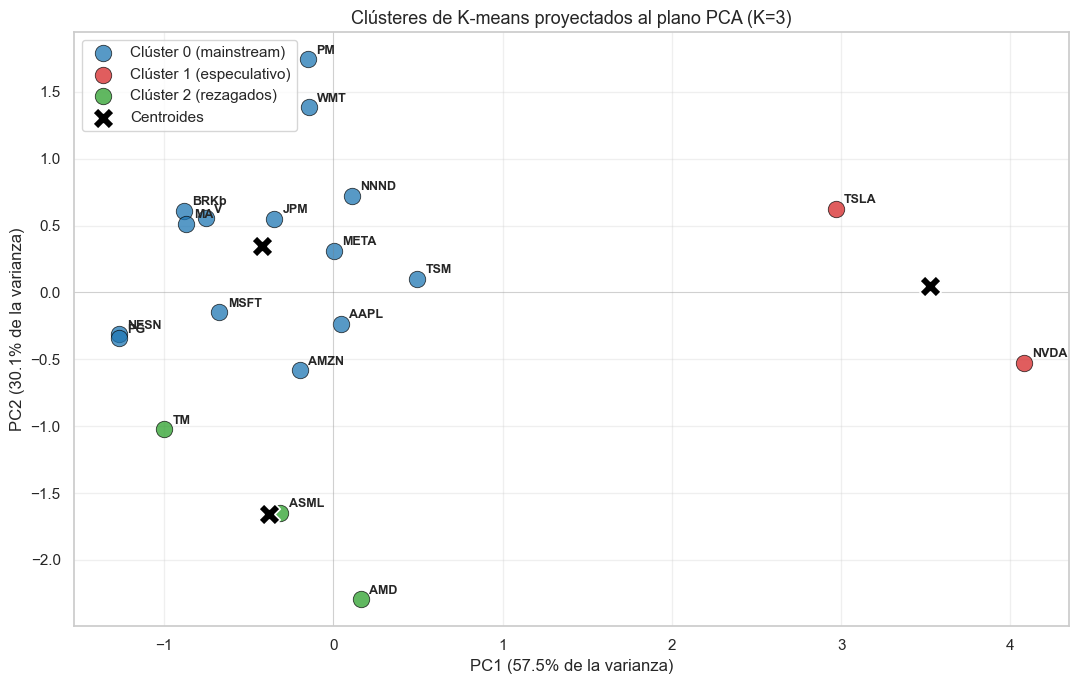

In [21]:
# Centroides de K-means proyectados al espacio PCA (la transformación es lineal,
# así que basta con aplicar pca.transform a las coordenadas escaladas de los centroides).
centroides_pca = pca.transform(modelo_kmeans.cluster_centers_)

fig, ax = plt.subplots(figsize=(11, 7))
colores_km = {0: "#1f77b4", 1: "#d62728", 2: "#2ca02c"}
nombres_km = {0: "Clúster 0 (mainstream)", 1: "Clúster 1 (especulativo)", 2: "Clúster 2 (rezagados)"}

for c in sorted(metricas_limpio["cluster_kmeans"].unique()):
    mask = metricas_limpio["cluster_kmeans"] == c
    ax.scatter(
        componentes_df.loc[mask, "PC1"],
        componentes_df.loc[mask, "PC2"],
        s=140, alpha=0.75, color=colores_km[c],
        edgecolor="black", linewidth=0.6,
        label=nombres_km[c],
    )

# Centroides.
ax.scatter(centroides_pca[:, 0], centroides_pca[:, 1],
           marker="X", s=240, c="black", linewidth=1.2,
           edgecolor="white", label="Centroides", zorder=5)

# Anotación de tickers — desplazamiento pequeño para no solapar el punto.
for ticker, (x, y) in componentes_df.iterrows():
    ax.annotate(ticker, xy=(x, y), xytext=(6, 4), textcoords="offset points",
                fontsize=9, fontweight="bold")

ax.axhline(0, color="gray", linewidth=0.5, alpha=0.4)
ax.axvline(0, color="gray", linewidth=0.5, alpha=0.4)
ax.set_xlabel(f"PC1 ({varianza[0]*100:.1f}% de la varianza)")
ax.set_ylabel(f"PC2 ({varianza[1]*100:.1f}% de la varianza)")
ax.set_title("Clústeres de K-means proyectados al plano PCA (K=3)")
ax.legend(loc="upper left")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Lectura del scatter K-means**:

- **`NVDA` y `TSLA` se separan netamente del resto** sobre el lado derecho del plano (PC1
  alto). La distancia entre el centroide del clúster 1 (especulativo) y los otros dos es
  varias veces mayor que la distancia entre los centroides de los clústeres 0 y 2 — la
  separación que K-means detectó no es marginal, es geométricamente clara.
- **El clúster 2 (`AMD`, `ASML`, `TM`)** se concentra en la **parte inferior del plano**
  (PC2 muy negativo: AMD ~−2.30, ASML ~−1.65, TM ~−1.02). Forman una franja horizontal
  bien definida que K-means logra aislar como grupo.
- **El clúster 0 (los 14 *mainstream*)** ocupa la nube central-izquierda, con cierta
  dispersión vertical: `PM` y `WMT` quedan arriba (PC2 alto), mientras que `AMZN` y `AAPL`
  bajan más cerca del clúster 2. Esto anticipa que dentro del grupo *mainstream* hay
  matices de comportamiento que retomaremos en §6.
- **Puntos en frontera**: `AMZN` (PC2 ≈ −0.58) y `AAPL` (PC2 ≈ −0.23) están más cerca del
  clúster 2 que del centroide de su propio clúster 0 si miramos solo PC2; K-means los
  asigna al clúster 0 porque considera las tres dimensiones originales, no la proyección.
  Conviene tenerlo en cuenta como una zona de transición.

### 5.3 Comparación visual con DBSCAN

Repetimos el plano con las etiquetas de DBSCAN. Los 17 tickers del clúster denso van en un
único color; los puntos marcados como **ruido** (etiqueta `-1`) van en gris para destacar
visualmente que el algoritmo los considera atípicos.

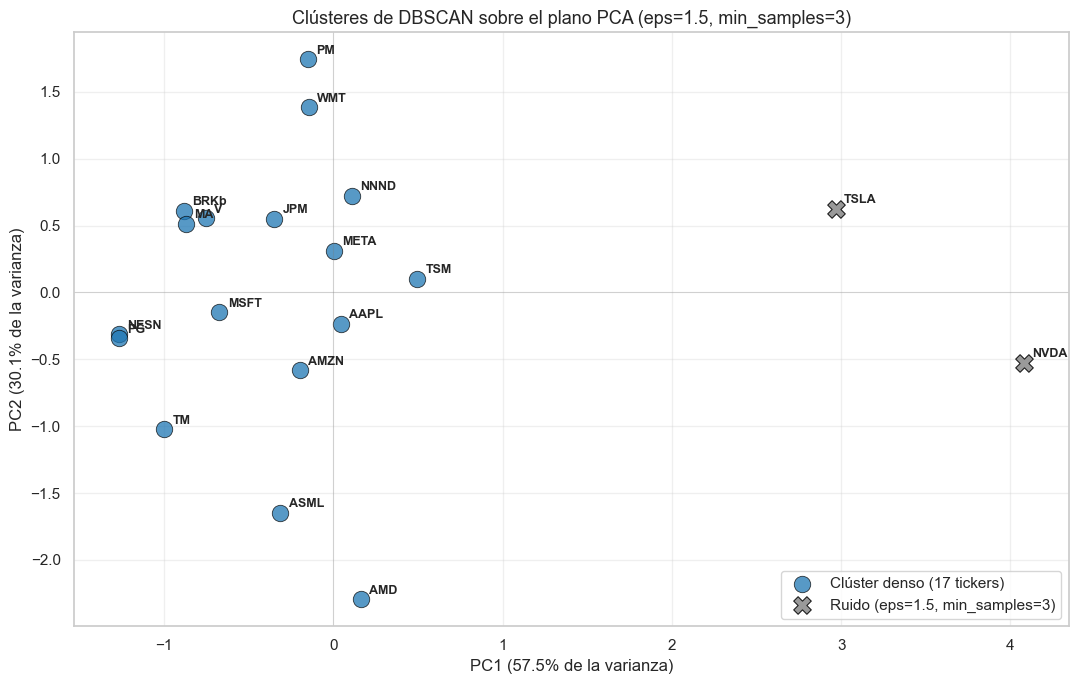

In [22]:
fig, ax = plt.subplots(figsize=(11, 7))

mask_ruido = metricas_limpio["cluster_dbscan"] == -1
mask_denso = ~mask_ruido

ax.scatter(
    componentes_df.loc[mask_denso, "PC1"],
    componentes_df.loc[mask_denso, "PC2"],
    s=140, alpha=0.75, color="#1f77b4",
    edgecolor="black", linewidth=0.6,
    label="Clúster denso (17 tickers)",
)
ax.scatter(
    componentes_df.loc[mask_ruido, "PC1"],
    componentes_df.loc[mask_ruido, "PC2"],
    s=160, alpha=0.85, color="#888888",
    edgecolor="black", linewidth=0.8, marker="X",
    label="Ruido (eps=1.5, min_samples=3)",
)

for ticker, (x, y) in componentes_df.iterrows():
    ax.annotate(ticker, xy=(x, y), xytext=(6, 4), textcoords="offset points",
                fontsize=9, fontweight="bold")

ax.axhline(0, color="gray", linewidth=0.5, alpha=0.4)
ax.axvline(0, color="gray", linewidth=0.5, alpha=0.4)
ax.set_xlabel(f"PC1 ({varianza[0]*100:.1f}% de la varianza)")
ax.set_ylabel(f"PC2 ({varianza[1]*100:.1f}% de la varianza)")
ax.set_title("Clústeres de DBSCAN sobre el plano PCA (eps=1.5, min_samples=3)")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Lectura del scatter DBSCAN**: la imagen confirma visualmente lo que la composición
numérica de §4.5 ya nos había dicho: `NVDA` y `TSLA` están **geográficamente aislados**
sobre el plano PCA. El clúster denso (azul) ocupa toda la franja izquierda hasta PC1 ≈ 0.5;
luego hay un **gap** de ~2.5 unidades en PC1 antes de llegar a TSLA, y otro salto adicional
hasta NVDA. Esa discontinuidad de densidad es exactamente lo que DBSCAN está capturando: no
es que NVDA y TSLA "no se parezcan" entre sí (de hecho K-means los junta), sino que **están
demasiado lejos del resto** para entrar en cualquier clúster denso definido por
proximidad.

### 5.4 *Loadings*: ¿qué representa cada eje?

Que la visualización capture el ~88% de la varianza es un buen indicio, pero falta
responder una pregunta más: **¿qué significan PC1 y PC2 en términos de las métricas
financieras originales?** Los *loadings* (`pca.components_`) son los pesos con los que
cada métrica original entra en cada componente. Inspeccionarlos nos permite traducir los
ejes a lenguaje de negocio.

Loadings (pesos de cada métrica original en cada componente):

                PC1    PC2
rentabilidad  0.365  0.918
volatilidad   0.641 -0.367
volumen_prom  0.675 -0.148


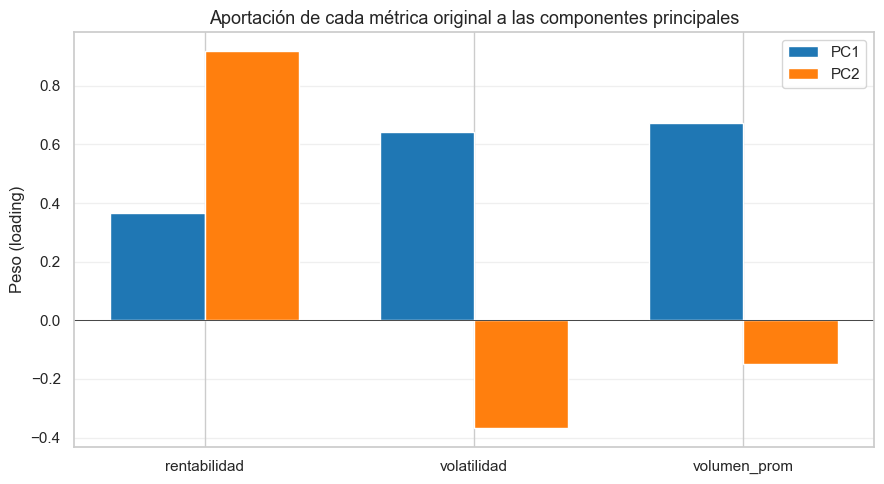

In [23]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=metricas_limpio.columns[:3],  # rentabilidad, volatilidad, volumen_prom
    columns=["PC1", "PC2"],
)
print("Loadings (pesos de cada métrica original en cada componente):\n")
print(loadings.round(3))

# Visualización: barras agrupadas por variable, una barra por componente.
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(loadings))
ancho = 0.35
ax.bar(x - ancho/2, loadings["PC1"], ancho, label="PC1", color="#1f77b4")
ax.bar(x + ancho/2, loadings["PC2"], ancho, label="PC2", color="#ff7f0e")
ax.axhline(0, color="black", linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(loadings.index)
ax.set_ylabel("Peso (loading)")
ax.set_title("Aportación de cada métrica original a las componentes principales")
ax.legend()
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

**Interpretación de los ejes**:

- **PC1 (eje horizontal — "intensidad de mercado")**: lo dominan **volumen promedio
  (0.67)** y **volatilidad (0.64)** con pesos casi iguales y del mismo signo, mientras
  que la rentabilidad aporta menos (0.37). Un ticker con PC1 alto es uno que combina
  **mucha actividad de transacción y mucho movimiento de precio**: el mercado lo está
  mirando y discutiendo intensamente. NVDA y TSLA son los exponentes extremos en este
  eje. Por el lado opuesto, `PG` y `NESN` (PC1 ≈ −1.27) son los más "tranquilos" — bajo
  volumen relativo y baja volatilidad.

- **PC2 (eje vertical — "calidad del retorno")**: lo domina la **rentabilidad (+0.92)**,
  mientras que volatilidad (−0.37) y volumen (−0.15) restan. Un ticker con PC2 alto es
  uno que ha tenido **rentabilidad media positiva fuerte sin requerir altos niveles de
  volatilidad o volumen** — un comportamiento de "subida silenciosa". `PM` y `WMT` son
  los que mejor encarnan ese perfil en el período. En la parte baja del eje aparecen los
  tres rezagados (AMD, ASML, TM) y AMZN, todos con rentabilidad cercana a cero o
  negativa.

**Por qué los clústeres caen donde caen**:

| Clúster | Posición en el plano | Lectura |
|---|---|---|
| 1 (NVDA, TSLA) | PC1 muy alto | Alta intensidad de mercado — alto volumen y alta volatilidad. |
| 2 (AMD, ASML, TM) | PC2 muy bajo | Baja calidad del retorno — rentabilidad negativa o nula. |
| 0 (los 14 *mainstream*) | Centro-izquierda, PC2 mixto | Intensidad moderada y rentabilidad positiva variable. |

Esta lectura cuadra con la denominación tentativa que usamos en §4.4 y prepara el terreno
para los nombres definitivos (defensivo / popular / especulativo / rezagados) que
asignaremos en **§6**, una vez que comparemos los valores medios de cada clúster en las
métricas originales.

## 6. Análisis e interpretación

Esta es la sección de mayor peso del proyecto: dos algoritmos ya nos entregaron particiones,
un PCA nos mostró que la separación es geométricamente real, pero todavía no hemos asignado
**nombres en español** a los clústeres ni los hemos traducido a **perfiles de inversor**.
Aquí cerramos ese círculo:

1. Calculamos las **medias por clúster** en las tres métricas — la base cuantitativa de la
   interpretación.
2. Asignamos a cada clúster una **etiqueta cualitativa en español** justificada con los
   números de la tabla.
3. Mapeamos cada clúster a un **perfil de inversor** (estabilidad, crecimiento, liquidez)
   y formulamos recomendaciones concretas.
4. Cerramos con una **comparación K-means vs DBSCAN** que confirma la coherencia entre
   ambos algoritmos.

### 6.1 Tabla resumen por clúster

Calculamos la media de las tres métricas dentro de cada clúster, junto con el conteo de
tickers y la lista de miembros. Esa tabla es la fotografía cuantitativa que sustentará todas
las decisiones interpretativas siguientes.

In [24]:
# Medias por clúster sobre las tres métricas originales (no escaladas).
resumen_clusters = (
    metricas_limpio
    .groupby("cluster_kmeans")[["rentabilidad", "volatilidad", "volumen_prom"]]
    .mean()
)
resumen_clusters["n_tickers"] = metricas_limpio.groupby("cluster_kmeans").size()
resumen_clusters["tickers"] = (
    metricas_limpio
    .groupby("cluster_kmeans")
    .apply(lambda g: ", ".join(g.index), include_groups=False)
)

# Reordenamos columnas para que la tabla se lea de izquierda a derecha
# como "tamaño → comportamiento → composición".
resumen_clusters = resumen_clusters[
    ["n_tickers", "rentabilidad", "volatilidad", "volumen_prom", "tickers"]
]
resumen_clusters.round(6)

,n_tickers,rentabilidad,volatilidad,volumen_prom,tickers
cluster_kmeans,,,,,
0,14,0.000970,0.017418,1.673733e+07,"AMZN, AAPL, BRKb, JPM, MA, META, MSFT, NESN, P..."
1,2,0.002189,0.041508,1.975352e+08,"NVDA, TSLA"
2,3,-0.000863,0.027416,1.476225e+07,"AMD, ASML, TM"


**Lectura de la tabla**:

- **Clúster 0 (14 tickers)** — rentabilidad media positiva moderada (~0.097% diaria),
  volatilidad **la más baja de los tres** (~1.74%) y volumen medio (~16.7 M acciones/día).
  Es el grupo de los activos *blue-chip* con comportamiento estable.
- **Clúster 1 (2 tickers: NVDA, TSLA)** — la **rentabilidad más alta** (~0.219% diaria,
  más del doble del clúster 0), pero también la **volatilidad más alta** (~4.15%, más del
  doble del clúster 0) y un volumen promedio que es **~12 veces** el del clúster 0
  (~197 M acciones/día). Alto retorno, alto riesgo, ultra-alta liquidez.
- **Clúster 2 (3 tickers: AMD, ASML, TM)** — la **única rentabilidad media negativa**
  (~−0.086% diaria), con volatilidad alta (~2.74%, ~58% mayor que el clúster 0). El
  volumen es similar al del clúster 0. Es el peor cuadrante riesgo/retorno: se asume
  volatilidad sin compensación en el período.

Como referencia, la mediana global del universo de 19 tickers fue rentabilidad
~0.101% / volatilidad ~1.92% / volumen ~14.5 M. El clúster 1 está claramente por encima
en las tres métricas, el clúster 2 por debajo en rentabilidad y por encima en
volatilidad, y el clúster 0 se ubica cerca de la mediana — confirmando su rol de
"comportamiento típico".

### 6.2 Etiquetas interpretativas en español

A partir de la tabla anterior, asignamos a cada clúster una etiqueta cualitativa que
captura su perfil financiero:

- **Clúster 0 → *Defensivo***. Volatilidad la más baja, rentabilidad positiva moderada,
  volumen medio. Reúne a los grandes pilares del mercado: financieros (BRKb, JPM, MA, V),
  consumo defensivo (PG, NESN, PM, WMT), tecnológicas consolidadas (AAPL, MSFT, META) y
  exportadores asiáticos (TSM, NNND). Son los activos que un inversor conservador
  pondría como núcleo de su portafolio.
- **Clúster 1 → *Especulativo***. Alta rentabilidad, alta volatilidad, volumen
  extraordinario. NVDA y TSLA son los dos *poster children* del rally tecnológico de
  2024-2025: los retornos son sustanciales pero el riesgo equivalente. Solo apropiados
  para inversores con alta tolerancia al drawdown.
- **Clúster 2 → *Rezagado***. Rentabilidad media negativa con volatilidad alta. AMD,
  ASML y TM compartieron en el período un patrón corrector: dieron pérdidas medias
  diarias asumiendo riesgo elevado. Esta etiqueta es **descriptiva del período
  observado** — no es un juicio sobre el valor fundamental de las empresas. En otra
  ventana temporal estos tickers podrían pertenecer a un clúster muy distinto.

> ⚠️ **Sobre las etiquetas que sugiere la guía**
> La guía PDF propone como ejemplo cuatro etiquetas: *defensivo*, *especulativo*,
> *popular* y *mixto*. Con $K=3$ no usamos las cuatro — el algoritmo no encontró un
> grupo que justifique la denominación *mixto*, y el rasgo *popular* (alto volumen) se
> distribuye dentro del clúster *defensivo* en lugar de formar su propio clúster.
> Volveremos sobre el matiz de "popular" más abajo, en la lectura cualitativa.

Cristalizamos las etiquetas en una tabla maestra que servirá de referencia para el
resto del análisis.

In [25]:
ETIQUETAS = {
    0: "Defensivo",
    1: "Especulativo",
    2: "Rezagado",
}
PERFILES = {
    0: "Estabilidad",
    1: "Crecimiento agresivo",
    2: "A evitar / oportunidad de recuperación",
}

resumen_etiquetado = resumen_clusters.copy()
resumen_etiquetado.insert(0, "etiqueta", resumen_etiquetado.index.map(ETIQUETAS))
resumen_etiquetado.insert(1, "perfil_inversor", resumen_etiquetado.index.map(PERFILES))
resumen_etiquetado.round(6)

,etiqueta,perfil_inversor,n_tickers,rentabilidad,volatilidad,volumen_prom,tickers
cluster_kmeans,,,,,,,
0,Defensivo,Estabilidad,14,0.000970,0.017418,1.673733e+07,"AMZN, AAPL, BRKb, JPM, MA, META, MSFT, NESN, P..."
1,Especulativo,Crecimiento agresivo,2,0.002189,0.041508,1.975352e+08,"NVDA, TSLA"
2,Rezagado,A evitar / oportunidad de recuperación,3,-0.000863,0.027416,1.476225e+07,"AMD, ASML, TM"


**Lectura cualitativa: el matiz "popular" dentro del clúster *Defensivo***

El clúster 0 contiene 14 tickers que comparten el estatus de *blue-chip* pero difieren
mucho en **volumen transado**. Si separamos el sub-grupo de mayor liquidez vemos un
patrón claro:

- **Sub-perfil "popular" (alto volumen, > 20 M/día)**: AAPL (~56 M), AMZN (~42 M),
  NNND (~26 M) y MSFT (~21 M). Son tickers en los que un inversor puede entrar y salir
  rápido sin mover el precio — útil para perfiles que valoran liquidez sobre todo.
- **Sub-perfil "defensivo puro" (volumen menor)**: PG, NESN, BRKb, MA, V, JPM, PM,
  META, TSM, WMT. Volumen entre ~2.5 M y ~18 M, volatilidad baja, rentabilidad media
  positiva. Núcleo conservador clásico.

Esta sub-clasificación **no proviene del algoritmo** — es una lectura humana sobre el
contenido del clúster que K-means trató como homogéneo. La incluimos porque enriquece
las recomendaciones de inversión que vienen a continuación.

### 6.3 Perfiles de inversor y recomendaciones

> 💡 **¿Qué es un perfil de inversor?**
> Un perfil de inversor describe la **tolerancia al riesgo** y los **objetivos
> financieros** de quien invierte. Tres perfiles son útiles aquí:
>
> - **Estabilidad**: prioridad en preservar capital y obtener rentabilidades modestas
>   pero consistentes. Tolera poca volatilidad.
> - **Crecimiento agresivo**: dispuesto a asumir alta volatilidad y posibles drawdowns
>   significativos a cambio de un retorno potencial mayor.
> - **Liquidez**: necesita poder entrar y salir de posiciones con rapidez sin afectar
>   el precio — habitual en estrategias de trading o gestión de tesorería.
>
> A estos tres perfiles canónicos sumamos un cuarto **comportamiento** observado en los
> datos: *evitar / mirar como oportunidad de recuperación* para los activos que dieron
> rendimiento negativo en el período.

**Recomendaciones por perfil**:

- **Inversor de estabilidad** → núcleo en el clúster *Defensivo*, con preferencia por el
  sub-grupo defensivo puro (PG, NESN, BRKb, MA, V, JPM, PM, WMT). Volatilidad baja,
  rentabilidad positiva moderada, retornos consistentes.
- **Inversor de crecimiento agresivo** → exposición controlada al clúster *Especulativo*
  (NVDA, TSLA). La rentabilidad histórica del período es atractiva, pero la volatilidad
  del 4.15% diario implica que los drawdowns pueden ser severos. Posición de portafolio
  pequeña en términos relativos a pesar del retorno esperado alto.
- **Inversor con prioridad en liquidez** → sub-perfil *popular* del clúster *Defensivo*
  (AAPL, AMZN, MSFT, NNND, WMT) — volumen alto y volatilidad moderada. Si la tolerancia
  al riesgo es mayor, NVDA y TSLA del clúster *Especulativo* tienen el mayor volumen del
  universo (~197 M acciones/día), aunque con la volatilidad del clúster.
- **Para el clúster *Rezagado*** (AMD, ASML, TM) → **evitar como inversión pasiva** en
  el corto plazo: el período observado fue de pérdidas con riesgo elevado. Sin embargo,
  pueden ser candidatos para una **estrategia contraria** ("*buy the dip*") si se cree
  que la corrección es temporal y se tiene horizonte de inversión más largo. Esa lectura
  excede el alcance de este análisis y requiere fundamentales de cada empresa.

Construimos una tabla compacta de **decisión** que resume todo lo anterior.

In [26]:
tabla_decision = pd.DataFrame({
    "clúster": [0, 1, 2],
    "etiqueta": ["Defensivo", "Especulativo", "Rezagado"],
    "perfil_inversor": ["Estabilidad", "Crecimiento agresivo", "A evitar / recuperación"],
    "tickers_recomendados": [
        "PG, NESN, BRKb, MA, V, JPM, PM, WMT (defensivos puros) | AAPL, AMZN, MSFT, NNND (sub-perfil popular, alta liquidez)",
        "NVDA, TSLA (con sizing prudente)",
        "AMD, ASML, TM (mirar con cautela / horizonte largo)",
    ],
    "uso_principal": [
        "Núcleo conservador del portafolio",
        "Apuesta de crecimiento, posición pequeña",
        "Evitar pasivo / oportunidad de turnaround activa",
    ],
}).set_index("clúster")
tabla_decision

,etiqueta,perfil_inversor,tickers_recomendados,uso_principal
clúster,,,,
0,Defensivo,Estabilidad,"PG, NESN, BRKb, MA, V, JPM, PM, WMT (defensivo...",Núcleo conservador del portafolio
1,Especulativo,Crecimiento agresivo,"NVDA, TSLA (con sizing prudente)","Apuesta de crecimiento, posición pequeña"
2,Rezagado,A evitar / recuperación,"AMD, ASML, TM (mirar con cautela / horizonte l...",Evitar pasivo / oportunidad de turnaround activa


### 6.4 Comparación K-means vs DBSCAN

Para cerrar la sección revisamos cómo se relacionan las dos particiones que generamos.
Una tabla cruzada (`pd.crosstab`) muestra cuántos tickers caen en cada combinación de
etiquetas (clúster K-means × clúster DBSCAN).

In [27]:
tabla_cruzada = pd.crosstab(
    metricas_limpio["cluster_kmeans"],
    metricas_limpio["cluster_dbscan"],
    rownames=["K-means"], colnames=["DBSCAN"], margins=True, margins_name="Total",
)
tabla_cruzada

DBSCAN,-1,0,Total
K-means,,,
0,0,14,14
1,2,0,2
2,0,3,3
Total,2,17,19


**Lo que dice la tabla cruzada**:

- **El clúster *Especulativo* de K-means coincide exactamente con el ruido de DBSCAN**:
  los 2 tickers (NVDA, TSLA) que K-means aísla como un grupo separado son los mismos
  que DBSCAN marca como `-1`. Es la validación más fuerte que podemos pedir: dos
  algoritmos de naturaleza distinta — uno basado en centroides, otro en densidad — coinciden
  en señalar exactamente los mismos puntos como atípicos.
- **Los clústeres *Defensivo* y *Rezagado* de K-means se funden en un único clúster
  denso para DBSCAN**. Esto no es una contradicción: simplemente refleja que la frontera
  entre AMD/ASML/TM y el resto de los *blue-chips* **no es un hueco de densidad** sino
  un gradiente. K-means la detecta porque sus centroides "tiran" cada grupo hacia su
  zona característica del espacio; DBSCAN no la detecta porque no hay un vacío
  geométrico que separar. Esta diferencia es **información**: nos dice que la
  segmentación *Defensivo* vs *Rezagado* es real pero más sutil que la de
  *Especulativo*, y por tanto debe interpretarse con más cuidado en la práctica.
- **Conclusión metodológica**: usar K-means y DBSCAN como herramientas complementarias
  permite separar lo robusto (NVDA y TSLA son atípicos sin lugar a dudas) de lo
  matizado (los rezagados son un sub-grupo coherente pero no aislado), y eso es
  exactamente la clase de lectura que un análisis riguroso debería entregar.

## 7. Conclusiones y limitaciones

Cerramos el análisis recogiendo los hallazgos más sólidos del proceso, reconociendo
con honestidad las limitaciones que enmarcan los resultados y proponiendo líneas
de mejora que llevarían el estudio a un nivel más profesional. La intención de
esta sección no es repetir lo que ya mostraron las gráficas y tablas, sino destilar
qué se aprendió del universo de 19 *tickers* analizados y bajo qué condiciones
las conclusiones son válidas.

### 7.1 Hallazgos principales

**1. NVDA y TSLA componen un perfil atípico validado por dos algoritmos independientes.**
La separación de estos dos *tickers* del resto del universo no es un artefacto del
método elegido: K-means los aísla como un clúster propio (*Especulativo*) y DBSCAN
los marca como ruido (`-1`). Que una técnica basada en centroides y otra basada en
densidad coincidan exactamente sobre los mismos dos puntos es la evidencia más
fuerte que este análisis puede ofrecer. Su volumen promedio es ~12 veces mayor que
el del resto y su volatilidad casi 2.4 veces más alta, mientras que su rentabilidad
diaria positiva (+0.22%) compensa solo parcialmente ese riesgo.

**2. AMD, ASML y TM revelan un patrón de riesgo no compensado.**
El clúster *Rezagado* combina rentabilidad media **negativa** (−0.086% diario) con
una volatilidad un 58% superior a la del clúster *Defensivo*. En la práctica esto
es la señal opuesta a lo que un inversor busca: más oscilación a cambio de pérdidas
sostenidas en la ventana analizada. Es un grupo pequeño pero coherente, y su
existencia justifica por qué K=3 era preferible a K=2 — sin él, este matiz se
habría perdido entre el resto.

**3. La mayoría del universo (74%) se comporta como mercado *mainstream*.**
14 de 19 *tickers* (AAPL, AMZN, BRKb, JPM, MA, META, MSFT, NESN, PG, PM, TSM, NNND,
V, WMT) caen en el clúster *Defensivo*: rentabilidad ligeramente positiva,
volatilidad moderada y volumen normal. Dentro de este grupo identificamos un
**sub-perfil "popular"** — AAPL, AMZN, MSFT, NNND y WMT con volumen >20M/día —
como lectura humana, no como sub-clúster algorítmico. Esta distinción enriquece
las recomendaciones sin inventar estructura que el método no encontró.

**4. La proyección PCA preserva el 87.6% de la varianza original.**
PC1 (intensidad de mercado: volumen + volatilidad) y PC2 (calidad del retorno:
rentabilidad descontada de riesgo) son ejes interpretables en lenguaje de
negocio. Esto significa que la visualización 2D del clustering es una
representación fiel del espacio original — no una simplificación que sacrifica
información para verse bien.

**5. K-means y DBSCAN se complementan, no compiten.**
K-means descubre estructura más fina (3 grupos) porque sus centroides "tiran" del
espacio incluso cuando no hay huecos de densidad. DBSCAN solo detecta lo que está
genuinamente aislado. Usados juntos, separan lo robusto (atípicos confirmados) de
lo matizado (gradientes que existen pero no son "huecos"). Esa lectura cruzada
es probablemente el aprendizaje metodológico más transferible del proyecto.

### 7.2 Limitaciones del análisis

Los resultados anteriores son sólidos en lo que muestran, pero el alcance del
estudio tiene varias fronteras que conviene declarar de forma explícita:

- **Ventana temporal corta y sesgada.** Los 250 días de operación cubren
  aproximadamente un año (mayo 2024 – mayo 2025), una etapa marcada por el
  *rally* de tecnológicas (NVDA, AMD) y por correcciones específicas en otros
  segmentos. Las etiquetas asignadas describen el comportamiento *en esta ventana*
  y no necesariamente generalizan a periodos más largos o de naturaleza distinta
  (recesión, lateralización, choques macro).
- **KO excluido por insuficiencia de datos.** Coca-Cola contaba con apenas 21 de
  250 días disponibles (8.4%), lo que obligó a sacarla del clustering. Esto
  significa que el universo final son 19 *tickers*, no 20.
- **El clúster *Especulativo* tiene n=2.** Cualquier conclusión sobre el
  "comportamiento típico" de este grupo se apoya en solo dos puntos. Estadísticamente
  es inestable: si NVDA o TSLA hubieran tenido un comportamiento distinto en los
  meses analizados, el clúster habría desaparecido o cambiado drásticamente.
- **PCA descarta el 12.4% de la varianza.** La visualización 2D es fiel pero no
  perfecta. Pueden existir matices entre *tickers* cercanos en el plano que en
  realidad están más separados en el espacio original de 3 dimensiones.
- **DBSCAN no encontró sub-estructura dentro del grupo principal.** Los 17
  *tickers* no especulativos forman una nube de densidad razonablemente uniforme,
  por lo que la división *Defensivo* vs *Rezagado* depende de un método (K-means)
  que impone particiones aunque no haya separadores naturales. Es información,
  pero también una advertencia: el límite entre estos dos perfiles no es nítido.
- **Las variables son exclusivamente de precio y volumen.** El análisis ignora
  fundamentales (PER, capitalización, sector, márgenes) que en la práctica
  profesional pesan tanto o más que el comportamiento bursátil reciente. Este es
  un análisis técnico-cuantitativo, no una recomendación de inversión integral.

### 7.3 Líneas de mejora para una versión 2

Aceptando las limitaciones anteriores, el siguiente paso natural sería extender
el estudio en estas direcciones:

- **Ventana temporal mayor.** Pasar de 1 año a 3-5 años permitiría cubrir al
  menos un cambio de régimen del mercado y comprobar si la segmentación se
  mantiene estable o si los *tickers* migran de clúster con el tiempo.
- **Métricas financieras adicionales.** Incorporar el **ratio de Sharpe** (retorno
  por unidad de riesgo), el ***drawdown* máximo** (peor pérdida acumulada desde
  un máximo) y la **desviación de pérdidas** (*downside deviation*) ofrecería una
  caracterización más rica del riesgo, especialmente del riesgo asimétrico que
  los inversores realmente temen.
- **Validación con clustering jerárquico.** Construir un dendrograma y comparar
  con la partición de K-means daría una validación visual e independiente de que
  K=3 es la elección correcta, sin depender de las heurísticas de codo y silueta.
  Esta técnica no se cubrió explícitamente en el curso, por lo que entraría como
  extensión deliberada.
- **Variables fundamentales y de mercado.** Añadir sector, capitalización
  bursátil, PER y márgenes operativos transformaría el ejercicio de "segmentación
  por comportamiento" a "segmentación por perfil completo". Probablemente
  cambiaría la composición de los clústeres y haría las recomendaciones más
  útiles para un inversor real.
- **Visualización avanzada (t-SNE / UMAP).** Para datasets más grandes y con más
  variables, técnicas no lineales como t-SNE o UMAP capturan estructura local
  que PCA no ve. Mencionarlo como mejora futura es honesto: no formaron parte
  del temario del curso, así que aplicarlo aquí habría sido fuera de alcance.
- **Estabilidad temporal de los clústeres.** Repetir el análisis sobre ventanas
  móviles (por ejemplo, recalcular las métricas y los clústeres cada 60 días)
  mostraría si los perfiles son persistentes o si los *tickers* cambian de
  identidad financiera con frecuencia. Es la forma rigurosa de pasar de "esta
  segmentación describe el último año" a "esta segmentación es estructural".

En conjunto, estas extensiones convertirían el análisis actual — sólido como
ejercicio de aplicación del temario — en un sistema utilizable en un contexto
profesional de gestión de carteras. Para los objetivos de este proyecto final,
sin embargo, la segmentación obtenida cumple con creces el alcance pedido:
identifica perfiles claros, los valida con dos algoritmos independientes y
los traduce a recomendaciones interpretables para diferentes tipos de inversor.